In [5]:
import pandas as pd
dataset = pd.read_csv('AAPL_data.csv')

dataset.shape
dataset.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [6]:
dataset=dataset.values
open_value=dataset[:,1]
print(open_value[:5])

[67.7142 68.0714 68.5014 66.7442 66.3599]


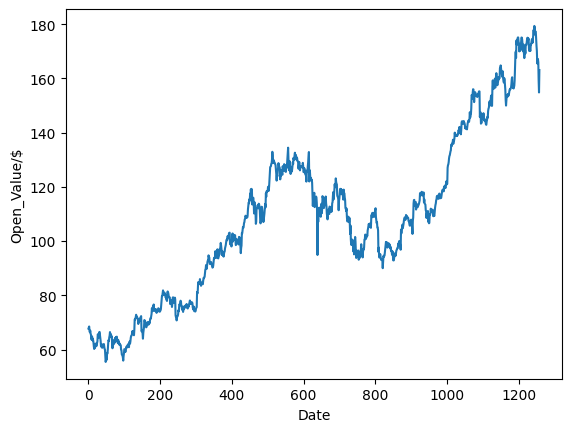

In [7]:
from matplotlib import pyplot as plt

plt.plot(open_value)
plt.xlabel('Date')
plt.ylabel('Open_Value/$')
plt.show()

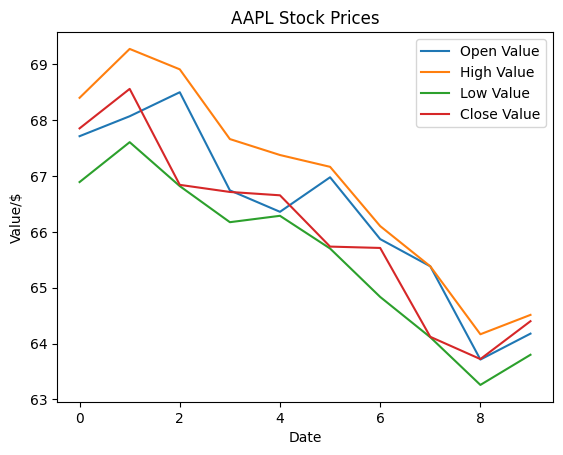

In [10]:
open_value=dataset[:,1]
high_value=dataset[:,2]
low_value=dataset[:,3]
close_value=dataset[:,4]

plt.plot(open_value[:10], label='Open Value')
plt.plot(high_value[:10], label='High Value')
plt.plot(low_value[:10], label='Low Value')
plt.plot(close_value[:10], label='Close Value')

plt.xlabel('Date')
plt.ylabel('Value/$')
plt.title('AAPL Stock Prices')
plt.legend()
plt.show()

In [11]:
open_value=open_value.reshape(-1,1)
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
scaled_open_value=scaler.fit_transform(open_value)

print(open_value[:5].T)
print(scaled_open_value[:5].T)



[[67.7142 68.0714 68.5014 66.7442 66.3599]]
[[0.09915624 0.10203815 0.10550741 0.09133024 0.08822969]]


In [13]:
data=[]
target=[]

window_size=50

for i in range(0,len(open_value)-window_size):
    data.append(scaled_open_value[i:i+window_size])
    target.append(scaled_open_value[i+window_size])


In [14]:
import numpy as np
data_np=np.array(data)
target_np=np.array(target)
print(data_np.shape)
print(target_np.shape)

(1209, 50, 1)
(1209, 1)


In [15]:
np.save('data',data)
np.save('target',target)